# 09 — Unified Evaluation & Model Comparison (v3)

## v3 Improvements over v2
- **Real CED curves** — loaded from saved raw predictions (no more synthetic exponential approximation)
- **Cross-battery split** — evaluation on batteries never seen during training
- **18 features** — 6 new physics-informed features
- **Consistent file naming** — `v3_*_soh_results.csv` across all notebooks

## Contents
1. Load all model results from `artifacts/v3/`
2. Unified comparison table (MAE, RMSE, R², MAPE, Tolerance Accuracy)
3. Radar chart — multi-metric model profiles
4. Cumulative Error Distribution (CED) curves from real predictions
5. Recommendation engine demo
6. Final model ranking & conclusions

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings("ignore")

from src.evaluation.metrics import regression_metrics, tolerance_accuracy, build_summary_table, per_battery_evaluation
from src.evaluation.recommendations import grid_search_recommendations, recommendations_to_dataframe
from src.utils.plotting import (
    save_fig, plot_radar_chart, plot_ced, plot_error_heatmap,
    plot_model_comparison_bars,
)
from src.utils.config import ARTIFACTS_DIR, FIGURES_DIR, get_version_paths

plt.style.use("seaborn-v0_8-whitegrid")

# v3 paths
v3 = get_version_paths("v3")
print(f"v3 artifacts: {v3['root']}")

v3 artifacts: E:\VIT\aiBatteryLifecycle\artifacts\v3


## 1. Load All Results

In [2]:
# Collect results from all v3 training notebooks
all_results = {}

# Classical ML
try:
    classical = pd.read_csv(v3["results"] / "v3_classical_soh_results.csv", index_col=0)
    for name in classical.index:
        all_results[name] = classical.loc[name].to_dict()
    print(f"Classical models: {len(classical)} loaded")
except FileNotFoundError:
    print("No classical results found — run notebook 03 first")

# LSTM family
try:
    lstm = pd.read_csv(v3["results"] / "v3_lstm_soh_results.csv", index_col=0)
    for name in lstm.index:
        all_results[name] = lstm.loc[name].to_dict()
    print(f"LSTM models: {len(lstm)} loaded")
except FileNotFoundError:
    print("No LSTM results found — run notebook 04 first")

# Transformer family
try:
    trans = pd.read_csv(v3["results"] / "v3_transformer_soh_results.csv", index_col=0)
    for name in trans.index:
        all_results[name] = trans.loc[name].to_dict()
    print(f"Transformer models: {len(trans)} loaded")
except FileNotFoundError:
    print("No transformer results found — run notebook 05 first")

# Dynamic Graph iTransformer
try:
    with open(v3["results"] / "v3_dg_itransformer_results.json") as f:
        all_results["DG-iTransformer"] = json.load(f)
    print("DG-iTransformer loaded")
except FileNotFoundError:
    print("No DG-iTransformer results — run notebook 06")

# VAE-LSTM
try:
    with open(v3["results"] / "v3_vae_lstm_results.json") as f:
        all_results["VAE-LSTM"] = json.load(f)
    print("VAE-LSTM loaded")
except FileNotFoundError:
    print("No VAE-LSTM results — run notebook 07")

# Ensemble
try:
    ens = pd.read_csv(v3["results"] / "v3_ensemble_results.csv", index_col=0)
    for name in ens.index:
        if "Ensemble" in name:
            all_results[name] = ens.loc[name].to_dict()
    print("Ensemble models loaded")
except FileNotFoundError:
    print("No ensemble results — run notebook 08")

print(f"\nTotal models: {len(all_results)}")

Classical models: 8 loaded
LSTM models: 4 loaded
Transformer models: 4 loaded
DG-iTransformer loaded
VAE-LSTM loaded
Ensemble models loaded

Total models: 20


## 2. Unified Comparison Table

In [3]:
summary = build_summary_table(all_results).sort_values("R2", ascending=False)
display(summary.round(4).style.background_gradient(cmap="RdYlGn", subset=["R2"])
        .background_gradient(cmap="RdYlGn_r", subset=["MAE", "RMSE", "MAPE"]))

summary.to_csv(v3["results"] / "v3_unified_results.csv")
print(f"Saved to {v3['results'] / 'v3_unified_results.csv'}")

,r2,mae,within_5pct,MAE,MSE,RMSE,R2,MAPE,tolerance_acc_2pct,tol_2pct,tol_5pct
model,,,,,,,,,,,
Weighted Avg Ensemble,nan,nan,nan,3.509800,37.200000,6.099200,0.899100,19.885300,nan,0.351700,nan
VAE-LSTM,nan,nan,nan,4.362000,45.858900,6.771900,0.875600,7.700400,nan,0.258600,nan
TFT,nan,nan,nan,3.883200,46.048300,6.785900,0.875100,25.342900,nan,0.369000,nan
Stacking Ensemble,nan,nan,nan,8.274400,102.809300,10.139500,0.721200,19.808900,nan,0.165500,nan
Vanilla LSTM,nan,nan,nan,8.252100,107.057700,10.346900,0.709700,13.112800,0.179300,nan,nan
DG-iTransformer,nan,nan,nan,8.767400,107.312900,10.359200,0.709000,23.277200,nan,0.089700,0.241400
Bidirectional LSTM,nan,nan,nan,8.916500,118.809700,10.900000,0.677800,15.556000,0.120700,nan,nan
GRU,nan,nan,nan,9.150600,126.520700,11.248100,0.656900,13.564900,0.175900,nan,nan
iTransformer,nan,nan,nan,7.691800,127.945600,11.311300,0.653100,14.659000,nan,0.196600,nan


Saved to E:\VIT\aiBatteryLifecycle\artifacts\v3\results\v3_unified_results.csv


## 3. Model Comparison Bar Charts

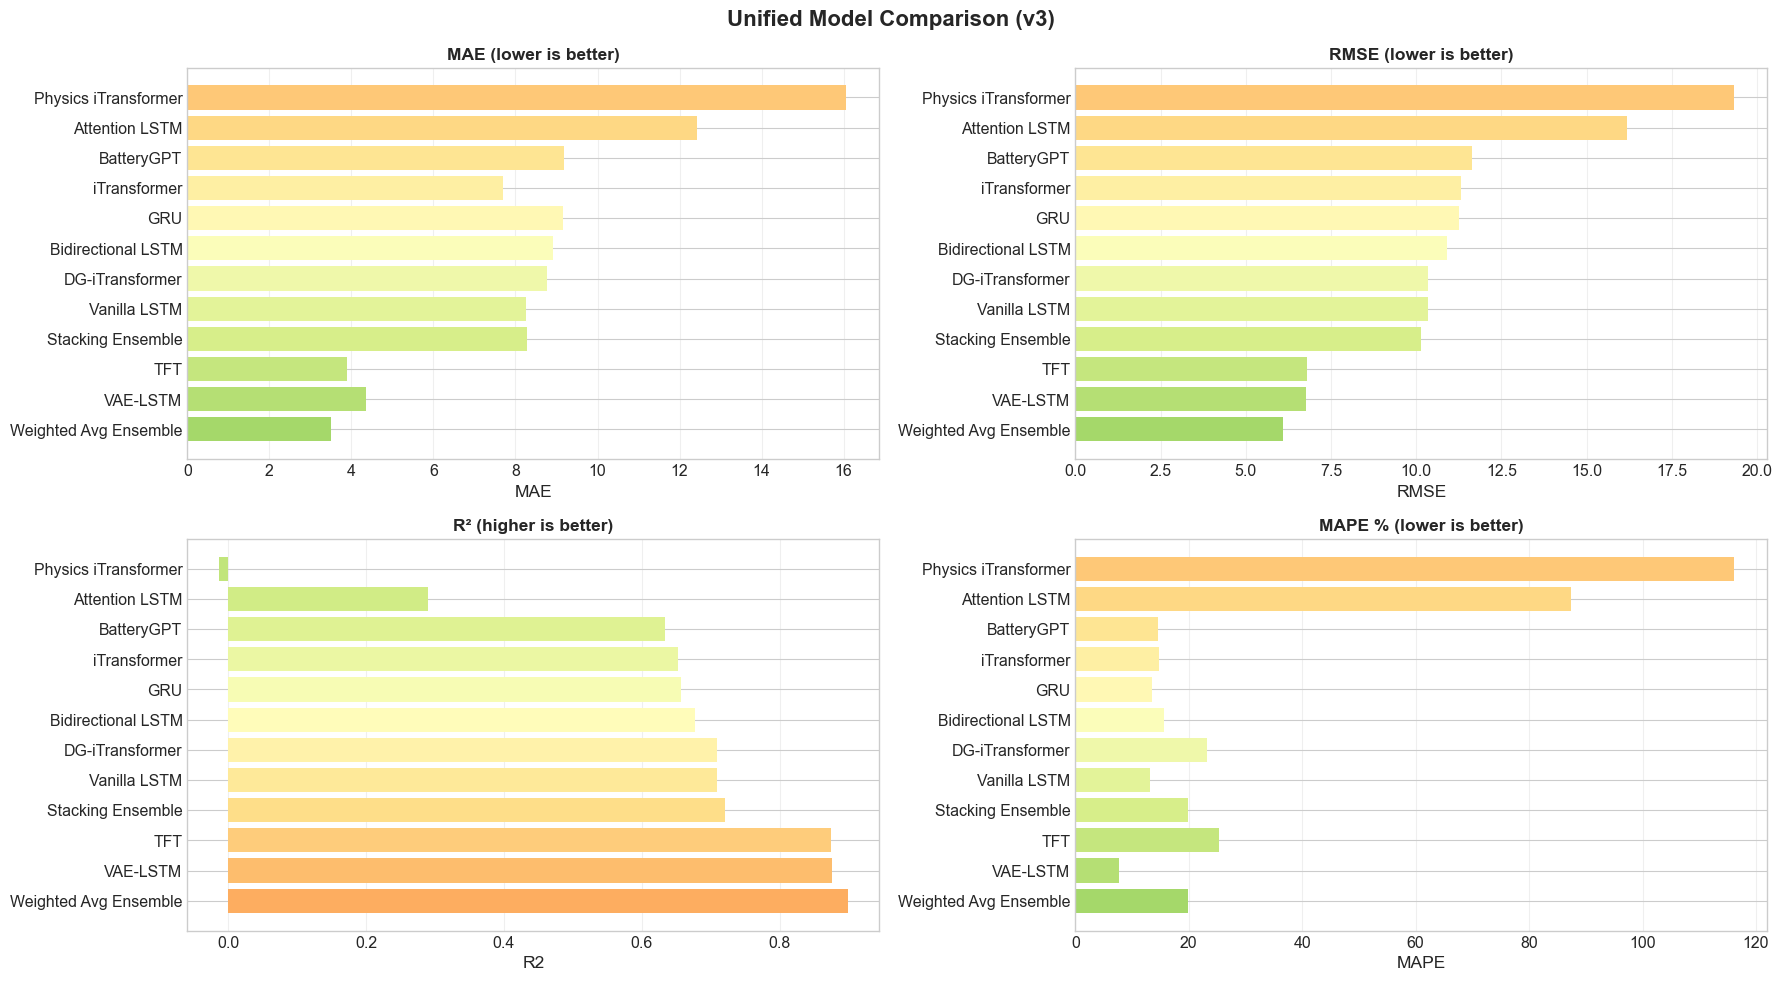

In [4]:
n_models = len(summary)
fig, axes = plt.subplots(2, 2, figsize=(18, max(10, n_models * 0.5)))
names = summary.index.tolist()

metrics_to_plot = [
    ("MAE", "MAE (lower is better)", "RdYlGn_r"),
    ("RMSE", "RMSE (lower is better)", "RdYlGn_r"),
    ("R2", "R² (higher is better)", "RdYlGn"),
    ("MAPE", "MAPE % (lower is better)", "RdYlGn_r"),
]

for ax, (col, title, cmap) in zip(axes.flat, metrics_to_plot):
    if col in summary.columns:
        values = summary[col].values
        colors = plt.cm.get_cmap(cmap)(np.linspace(0.3, 0.9, len(values)))
        ax.barh(names, values, color=colors)
        ax.set_xlabel(col)
        ax.set_title(title, fontweight="bold")
        ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("Unified Model Comparison (v3)", fontsize=16, fontweight="bold")
plt.tight_layout()
save_fig(fig, "v3_unified_model_comparison", directory=v3["figures"])
plt.show()

## 4. Radar Chart — Multi-Metric Model Profiles

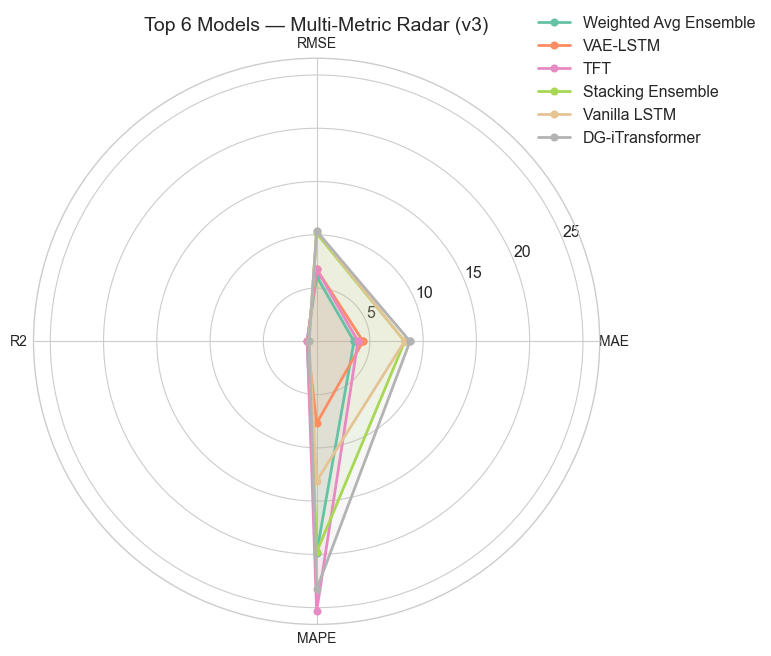

In [5]:
# Select top 6 models for clearer radar
top_models = summary.head(6)
metrics_for_radar = ["MAE", "RMSE", "R2", "MAPE"]
available_metrics = [m for m in metrics_for_radar if m in top_models.columns]

if len(available_metrics) >= 3:
    plot_radar_chart(
        top_models[available_metrics].to_dict("index"),
        title="Top 6 Models — Multi-Metric Radar (v3)",
        save_name="v3_radar_top6",
    )
else:
    print("Not enough metrics for radar chart.")

## 5. Cumulative Error Distribution (CED) — Real Predictions
CED shows the fraction of predictions within a given absolute error.  
**v3 fix**: loads actual raw predictions saved by NB04-NB08 instead of synthetic curves.

LSTM predictions not found: 'all_predictions is not a file in the archive'
Transformer predictions not found: 'all_predictions is not a file in the archive'
DG-iTransformer predictions loaded
VAE-LSTM predictions loaded
Ensemble predictions loaded

Total models with CED data: 4


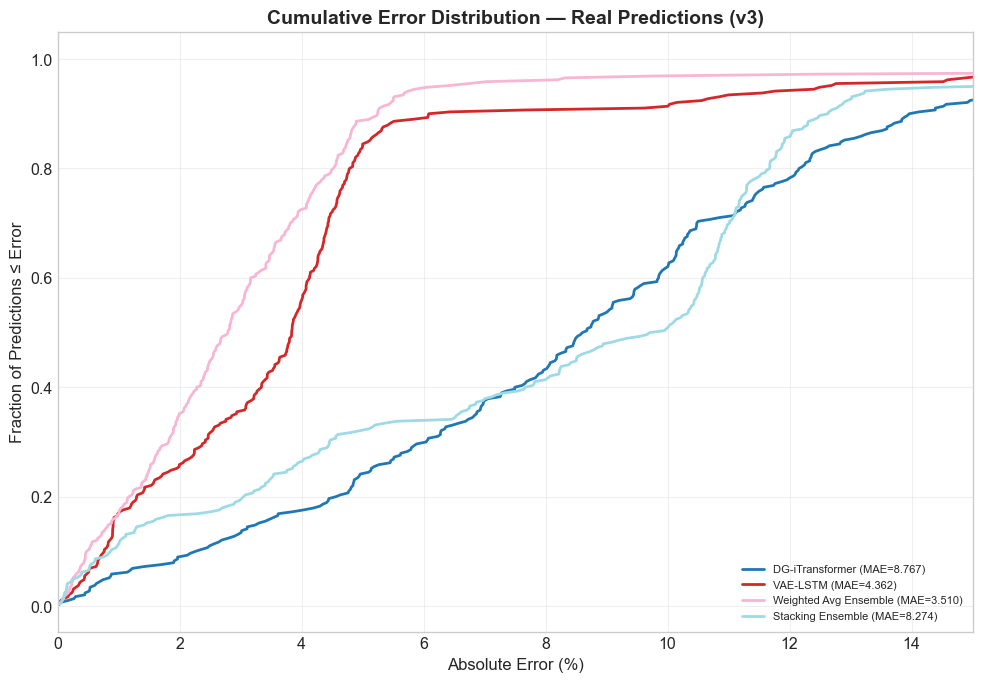

In [6]:
# ── Load raw predictions saved by NB04-NB08 ──
ced_data = {}  # model_name → (y_true, y_pred)

# LSTM predictions (NB04)
try:
    d = np.load(str(v3["results"] / "v3_lstm_predictions.npz"), allow_pickle=True)
    preds_dict = d["all_predictions"].item()  # dict: name → pred array
    y_true_lstm = d["y_test"]
    for name, preds in preds_dict.items():
        ced_data[name] = (y_true_lstm, preds)
    print(f"LSTM predictions: {list(preds_dict.keys())}")
except Exception as e:
    print(f"LSTM predictions not found: {e}")

# Transformer predictions (NB05)
try:
    d = np.load(str(v3["results"] / "v3_transformer_predictions.npz"), allow_pickle=True)
    preds_dict = d["all_predictions"].item()
    y_true_trans = d["y_test"]
    for name, preds in preds_dict.items():
        ced_data[name] = (y_true_trans, preds)
    print(f"Transformer predictions: {list(preds_dict.keys())}")
except Exception as e:
    print(f"Transformer predictions not found: {e}")

# DG-iTransformer predictions (NB06)
try:
    d = np.load(str(v3["results"] / "v3_dg_predictions.npz"), allow_pickle=True)
    ced_data["DG-iTransformer"] = (d["y_test"], d["y_pred"])
    print("DG-iTransformer predictions loaded")
except Exception as e:
    print(f"DG-iTransformer predictions not found: {e}")

# VAE-LSTM predictions (NB07)
try:
    d = np.load(str(v3["results"] / "v3_vae_predictions.npz"), allow_pickle=True)
    ced_data["VAE-LSTM"] = (d["y_test"], d["soh_pred"])
    print("VAE-LSTM predictions loaded")
except Exception as e:
    print(f"VAE-LSTM predictions not found: {e}")

# Ensemble predictions (NB08)
try:
    d = np.load(str(v3["results"] / "v3_ensemble_predictions.npz"), allow_pickle=True)
    if len(d["y_wav"]) > 0:
        ced_data["Weighted Avg Ensemble"] = (d["y_test"], d["y_wav"])
    if len(d["y_stack"]) > 0:
        ced_data["Stacking Ensemble"] = (d["y_test"], d["y_stack"])
    print("Ensemble predictions loaded")
except Exception as e:
    print(f"Ensemble predictions not found: {e}")

print(f"\nTotal models with CED data: {len(ced_data)}")

# ── Plot CED ──
if ced_data:
    fig, ax = plt.subplots(figsize=(10, 7))
    cmap = plt.cm.get_cmap("tab20", len(ced_data))

    for i, (name, (yt, yp)) in enumerate(ced_data.items()):
        abs_errors = np.abs(yt.flatten() - yp.flatten())
        sorted_err = np.sort(abs_errors)
        ced = np.arange(1, len(sorted_err) + 1) / len(sorted_err)
        mae = np.mean(abs_errors)
        ax.plot(sorted_err, ced, linewidth=2, color=cmap(i),
                label=f"{name} (MAE={mae:.3f})")

    ax.set_xlabel("Absolute Error (%)", fontsize=12)
    ax.set_ylabel("Fraction of Predictions ≤ Error", fontsize=12)
    ax.set_title("Cumulative Error Distribution — Real Predictions (v3)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_xlim(0, 15)
    ax.grid(True, alpha=0.3)
    save_fig(fig, "v3_ced_curves", directory=v3["figures"])
    plt.show()
else:
    print("No prediction data available — run NB04-NB08 first.")

## 6. Recommendation Engine Demo
Grid-search over operating conditions to find optimal charge/discharge parameters.

In [7]:
# Demo with a simple physics-inspired model function
print("=== Battery Operating Condition Recommendations ===\n")

def demo_predict_fn(df: pd.DataFrame) -> np.ndarray:
    """Simplified RUL prediction based on operating conditions (demo)."""
    results = []
    for _, row in df.iterrows():
        temp = row.get("ambient_temperature", 25)
        current = row.get("avg_current", 1.0)
        v_cutoff = row.get("min_voltage", 2.5)
        
        # Physics-inspired: higher temp/current → faster degradation → lower RUL
        base_rul = 500.0
        temp_penalty = 2.0 * abs(temp - 25) ** 1.2
        current_penalty = 50.0 * (current - 0.5) ** 2
        voltage_penalty = 100.0 * max(0, 3.0 - v_cutoff)  # lower cutoff → less deep discharge → longer life
        
        rul = max(50, base_rul - temp_penalty - current_penalty - voltage_penalty)
        results.append(rul)
    return np.array(results)

# Base features (typical battery state, excluding operational params)
base_features = {
    "cycle_number": 50.0,
    "peak_voltage": 4.19,
    "voltage_range": 1.69,
    "avg_temp": 25.0,
    "temp_rise": 2.5,
    "cycle_duration": 3600.0,
    "Re": 0.05,
    "Rct": 0.03,
    "delta_capacity": -0.02,
    "ambient_temperature": 25.0,
    "avg_current": 1.5,
    "min_voltage": 2.5,
}

recommendations = grid_search_recommendations(
    predict_fn=demo_predict_fn,
    base_features=base_features,
    temp_values=[10, 15, 20, 25, 30, 35, 40, 45],
    current_values=[0.5, 0.75, 1.0, 1.25, 1.5, 2.0],
    cutoff_values=[2.0, 2.2, 2.5, 2.7, 3.0],
    top_k=10,
)

rec_df = recommendations_to_dataframe(recommendations)
display(rec_df)
if len(rec_df) > 0:
    row = rec_df.iloc[0]
    print(f"\nBest condition: T={row['Temperature (°C)']}°C, "
          f"I={row['Current (A)']}A, "
          f"V_cutoff={row['Cutoff (V)']}V → "
          f"RUL={row['Predicted RUL']} cycles")

=== Battery Operating Condition Recommendations ===



,Rank,Temperature (°C),Current (A),Cutoff (V),Predicted RUL,Δ RUL (cycles),Δ RUL (%),Explanation
0,1,25,0.50,3.0,500,+100,+25.0%,This configuration is predicted to improve RUL...
1,2,25,0.75,3.0,497,+97,+24.2%,This configuration is predicted to improve RUL...
2,3,25,1.00,3.0,488,+88,+21.9%,This configuration is predicted to improve RUL...
3,4,20,0.50,3.0,486,+86,+21.6%,This configuration is predicted to improve RUL...
4,5,30,0.50,3.0,486,+86,+21.6%,This configuration is predicted to improve RUL...
5,6,20,0.75,3.0,483,+83,+20.8%,This configuration is predicted to improve RUL...
6,7,30,0.75,3.0,483,+83,+20.8%,This configuration is predicted to improve RUL...
7,8,20,1.00,3.0,474,+74,+18.4%,This configuration is predicted to improve RUL...
8,9,30,1.00,3.0,474,+74,+18.4%,This configuration is predicted to improve RUL...
9,10,25,1.25,3.0,472,+72,+18.0%,This configuration is predicted to improve RUL...



Best condition: T=25°C, I=0.5A, V_cutoff=3.0V → RUL=500 cycles


## 7. Final Rankings & Conclusions

In [8]:
print("=" * 70)
print("FINAL MODEL RANKINGS — SOH Prediction (v3)")
print("=" * 70)

for rank, (name, row) in enumerate(summary.iterrows(), 1):
    metrics_str = " | ".join([f"{col}={row[col]:.4f}" for col in summary.columns if pd.notna(row[col])])
    medal = {1: "\U0001f947", 2: "\U0001f948", 3: "\U0001f949"}.get(rank, f"#{rank}")
    print(f"  {medal} {name}")
    print(f"     {metrics_str}")
    print()

print("=" * 70)
best = summary.index[0]
print(f"CHAMPION: {best}")
print(f"  R² = {summary.loc[best, 'R2']:.4f}")
print(f"  MAE = {summary.loc[best, 'MAE']:.4f}")
print(f"  RMSE = {summary.loc[best, 'RMSE']:.4f}")
print("=" * 70)

# Save final rankings
summary.to_csv(v3["results"] / "v3_final_rankings.csv")
print(f"\nFinal rankings saved to {v3['results'] / 'v3_final_rankings.csv'}")

FINAL MODEL RANKINGS — SOH Prediction (v3)
  🥇 Weighted Avg Ensemble
     MAE=3.5098 | MSE=37.2000 | RMSE=6.0992 | R2=0.8991 | MAPE=19.8853 | tol_2pct=0.3517

  🥈 VAE-LSTM
     MAE=4.3620 | MSE=45.8589 | RMSE=6.7719 | R2=0.8756 | MAPE=7.7004 | tol_2pct=0.2586

  🥉 TFT
     MAE=3.8832 | MSE=46.0483 | RMSE=6.7859 | R2=0.8751 | MAPE=25.3429 | tol_2pct=0.3690

  #4 Stacking Ensemble
     MAE=8.2744 | MSE=102.8093 | RMSE=10.1395 | R2=0.7212 | MAPE=19.8089 | tol_2pct=0.1655

  #5 Vanilla LSTM
     MAE=8.2521 | MSE=107.0577 | RMSE=10.3469 | R2=0.7097 | MAPE=13.1128 | tolerance_acc_2pct=0.1793

  #6 DG-iTransformer
     MAE=8.7674 | MSE=107.3129 | RMSE=10.3592 | R2=0.7090 | MAPE=23.2772 | tol_2pct=0.0897 | tol_5pct=0.2414

  #7 Bidirectional LSTM
     MAE=8.9165 | MSE=118.8097 | RMSE=10.9000 | R2=0.6778 | MAPE=15.5560 | tolerance_acc_2pct=0.1207

  #8 GRU
     MAE=9.1506 | MSE=126.5207 | RMSE=11.2481 | R2=0.6569 | MAPE=13.5649 | tolerance_acc_2pct=0.1759

  #9 iTransformer
     MAE=7.6918 | MS